In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.feature_selection import RFECV

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from imblearn.under_sampling import NearMiss
from sklearn.metrics import roc_curve, roc_auc_score

from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score, recall_score

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score

from sklearn.metrics import confusion_matrix
from sklearn.inspection import permutation_importance
import eli5

from sklearn.preprocessing import StandardScaler
from scipy.stats import spearmanr
from scipy.cluster import hierarchy
from scipy.spatial.distance import squareform
from collections import defaultdict

In [ ]:
plt.rc("font", family="Malgun Gothic")
plt.rc("axes", unicode_minus=False)

In [ ]:
df = pd.read_csv("data/healthcare-dataset-stroke-data.csv") # 데이터 불러오기

In [ ]:
data = pd.read_csv("data/stroke final data.csv")

In [ ]:
data_age_70 = pd.read_csv("data/data_age_70.csv")
age70_index = data_age_70["index"]

In [ ]:
column_unique = ['gender', 'hypertension', 'heart_disease',  # unique 값을 보고싶은 열만 변수에 저장
                 'ever_married','work_type', 'Residence_type', 
                 'smoking_status', 'stroke']

In [ ]:
for i in column_unique: # 각 행별로 어떤 값들이 있는지 
    a = df[i].unique()
    print(a)

['Male' 'Female' 'Other']
[0 1]
[1 0]
['Yes' 'No']
['Private' 'Self-employed' 'Govt_job' 'children' 'Never_worked']
['Urban' 'Rural']
['formerly smoked' 'never smoked' 'smokes' 'Unknown']
[1 0]


In [ ]:
df.info() # 결측값 확인 / age 실수인것 확인

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   object 
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   object 
 6   work_type          5110 non-null   object 
 7   Residence_type     5110 non-null   object 
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   object 
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 479.2+ KB


# 전처리

## 시각화

In [ ]:
data_original = pd.read_csv("data/healthcare-dataset-stroke-data.csv")
# id 열은 필요 없으니까 삭제
data_original = data_original.drop(columns="id",axis=1)

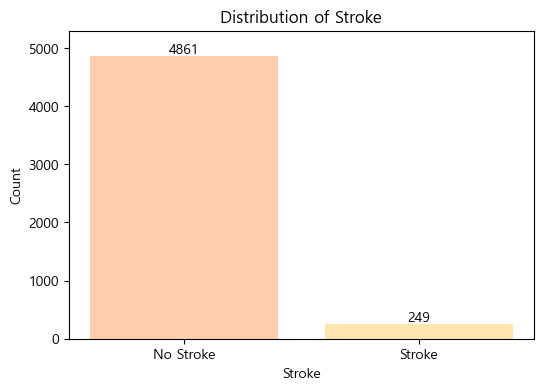

In [ ]:
# 0과 1의 개수 계산
num_zeros = data_original['stroke'].value_counts()[0]
num_ones = data_original['stroke'].value_counts()[1]

# 그림 크기 조정
plt.figure(figsize=(6, 4))

colors = ['#FFCFAF', '#FFE6AF', '#FFFAAF', '#DFFF9F']

# 시각화
plt.bar(['No Stroke', 'Stroke'], [num_zeros, num_ones], color = colors)
plt.xlabel('Stroke')
plt.ylabel('Count')
plt.title('Distribution of Stroke')
plt.ylim(0, 5300)  # y 범위 설정 (start, end)

# 개수를 그래프에 텍스트로 표시
plt.text(0, num_zeros, f'{num_zeros}', ha='center', va='bottom')
plt.text(1, num_ones, f'{num_ones}', ha='center', va='bottom')


plt.show()

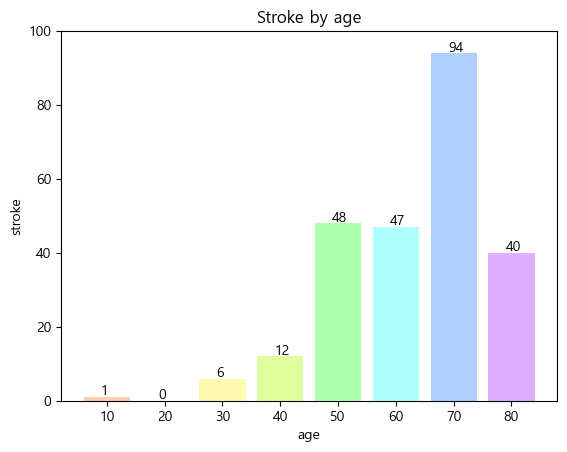

In [ ]:
def age_categorize(age):
  age = (age// 10) *10
  return age

age_category = data_original.age.apply(age_categorize)
age_category

data_original_age = data_original.copy()
data_original_age['age_category'] = age_category
data_original_age

# 리스트 만들기
stroke = []
age = []

for i in range(1,9):
  age.append(i*10)
  a = data_original_age.loc[data_original_age['age_category'] == i * 10.0]
  stroke.append(a['stroke'].sum())

xs = [i for i, _ in enumerate(age)]
colors = ['#FFCFAF', '#FFE6AF', '#FFFAAF', '#DFFF9F', '#AFFFAF', '#AFFFFF', '#AFCFFF', '#DFAFFF']

plt.bar(xs, stroke,color=colors)  # 해당 인덱스에 일치하는 값을 가진, 바 형태 그래프 생성
plt.xlabel("age")
plt.ylabel("stroke")
plt.xticks([i for i, _ in enumerate(age)], age)  # x 눈금 및 레이블 설정 
plt.title("Stroke by age")
plt.ylim(0, 100)  # y 범위 설정 (start, end)

for index, value in enumerate(stroke):
  plt.text(index - 0.1, value + 0.5, str(value))  # x 좌표, y 좌표, text
plt.show()

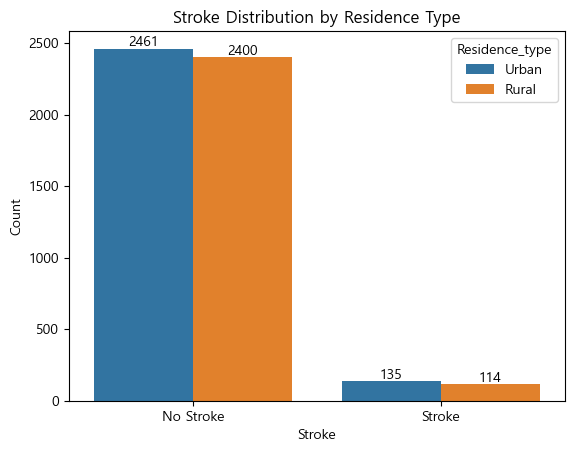

In [ ]:
# 시각화
ax = sns.countplot(x='stroke', hue='Residence_type', data=data_original)
plt.xlabel('Stroke')
plt.ylabel('Count')
plt.title('Stroke Distribution by Residence Type')

# 각 막대에 개수 표시
for p in ax.patches:
    height = int(p.get_height())
    ax.text(p.get_x() + p.get_width() / 2, height, height, ha='center', va='bottom')

# x축 레이블 수정
ax.set_xticklabels(['No Stroke', 'Stroke'])

plt.show()


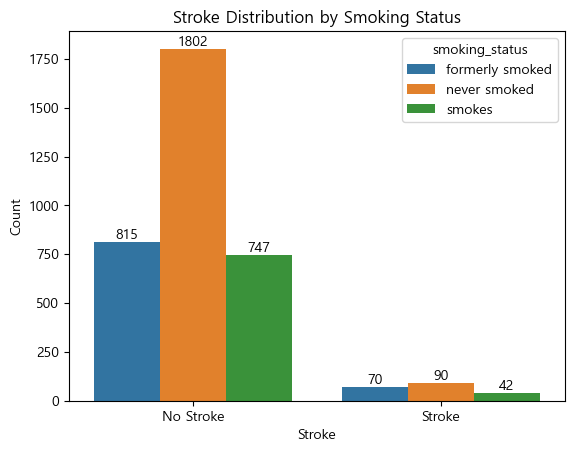

In [ ]:
# 'Unknown' 제외한 데이터 필터링
data_original = data_original[data_original['smoking_status'] != 'Unknown']

# 시각화
ax = sns.countplot(x='stroke', hue='smoking_status', data= data_original)
plt.xlabel('Stroke')
plt.ylabel('Count')
plt.title('Stroke Distribution by Smoking Status')

# x축 레이블 수정
ax.set_xticklabels(['No Stroke', 'Stroke'])

# 각 막대에 개수 표시
for p in ax.patches:
    height = int(p.get_height())
    ax.text(p.get_x() + p.get_width() / 2, height, height, ha='center', va='bottom')

plt.show()

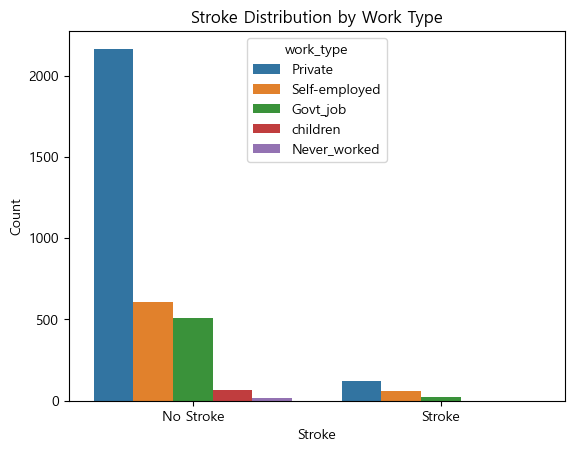

In [ ]:
# 시각화
ax = sns.countplot(x='stroke', hue='work_type', data =data_original)
plt.xlabel('Stroke')
plt.ylabel('Count')
plt.title('Stroke Distribution by Work Type')

# x축 레이블 수정
ax.set_xticklabels(['No Stroke', 'Stroke'])

plt.show()


- 혈당수준에 따른 분포

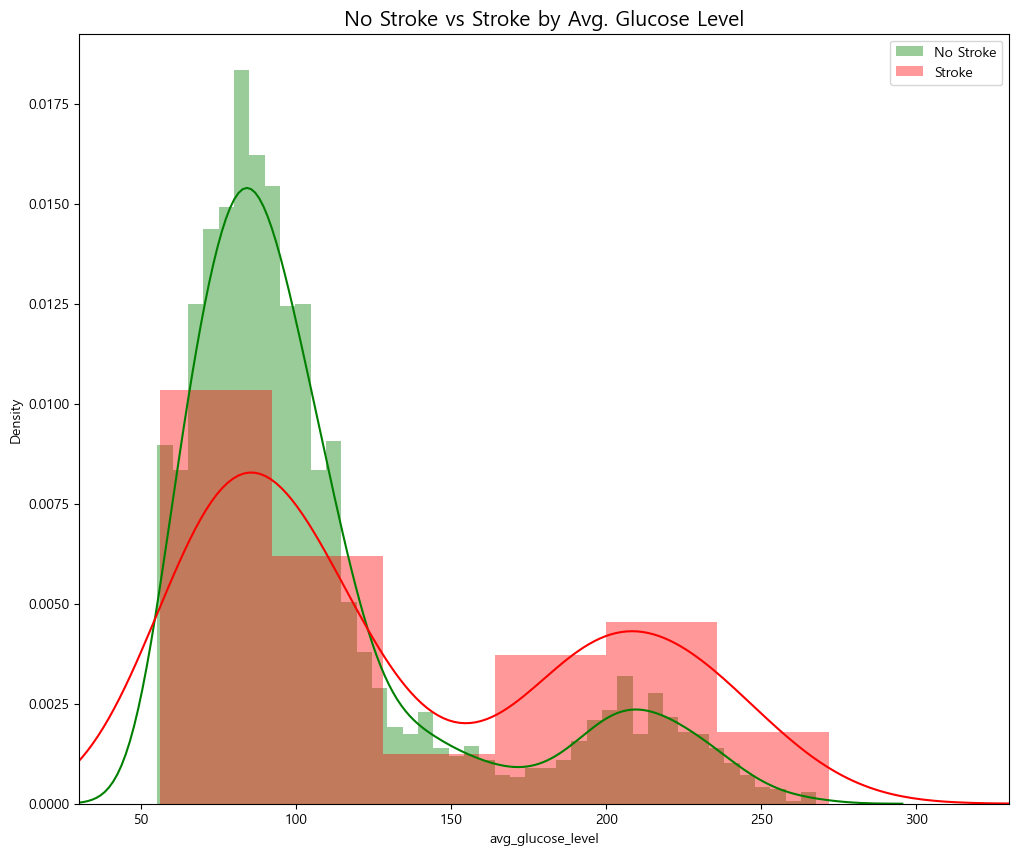

In [ ]:
plt.figure(figsize=(12,10))

sns.distplot(data_original[data_original['stroke'] == 0]["avg_glucose_level"], color='green', label='No Stroke') # No Stroke - green
sns.distplot(data_original[data_original['stroke'] == 1]["avg_glucose_level"], color='red', label='Stroke') # Stroke - Red

plt.title('No Stroke vs Stroke by Avg. Glucose Level', fontsize=15)
plt.xlim([30,330])

# 범례 추가
plt.legend()

plt.show()

- bmi 수준에 따른 분포

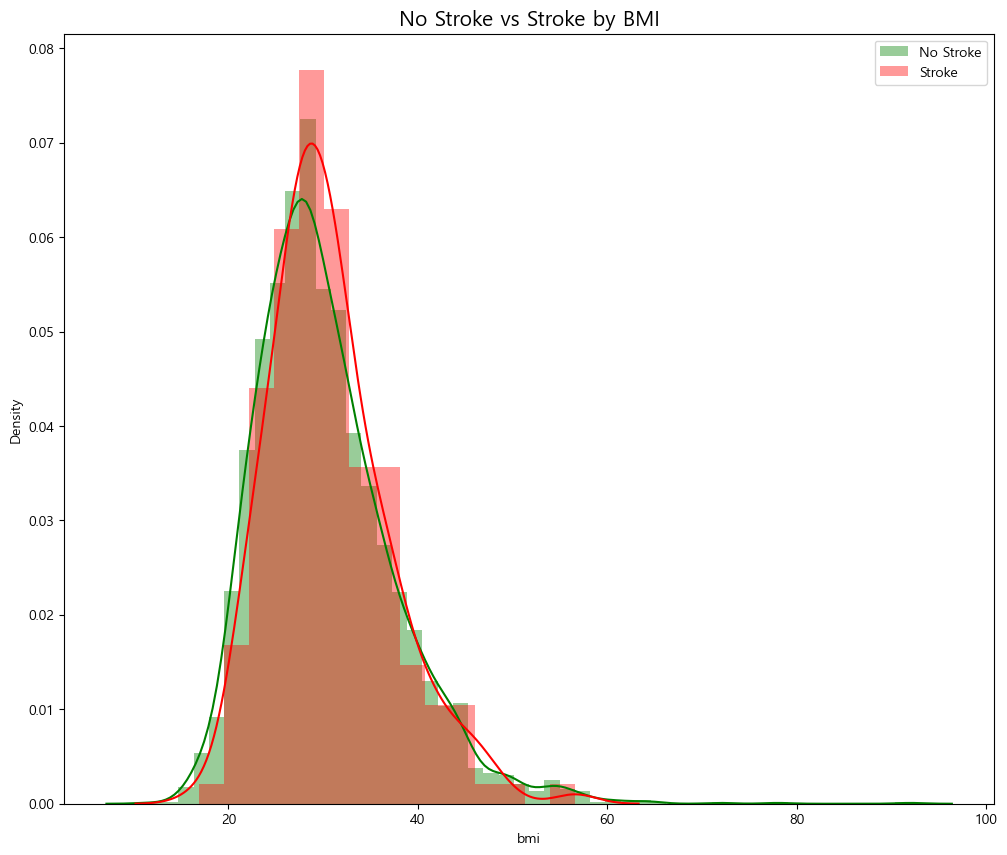

In [ ]:
plt.figure(figsize=(12,10))

sns.distplot(data_original[data_original['stroke'] == 0]["bmi"], color='green', label='No Stroke') # No Stroke - green
sns.distplot(data_original[data_original['stroke'] == 1]["bmi"], color='red', label='Stroke') # Stroke - Red

plt.title('No Stroke vs Stroke by BMI', fontsize=15)

# 범례 추가
plt.legend()

plt.show()

## 이상치 
- gender

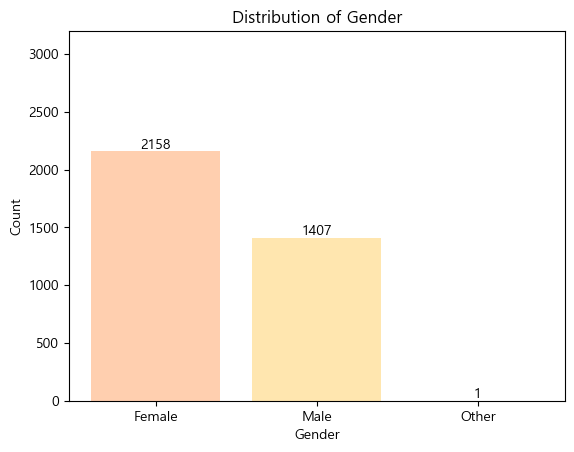

In [ ]:
# 성별 칼럼 값의 개수 계산
value_counts = data_original['gender'].value_counts()

colors = ['#FFCFAF', '#FFE6AF', '#FFFAAF', '#DFFF9F']

# 시각화
plt.bar(value_counts.index, value_counts.values, color = colors)
plt.xlabel('Gender')
plt.ylabel('Count')
plt.title('Distribution of Gender')
plt.ylim(0, 3200)
for i, count in enumerate(value_counts.values):
    plt.text(i, count, f'{count}', ha='center', va='bottom')

plt.show()


In [ ]:
df["gender"].value_counts() #  한 개밖에 없어서 제거 결정

Female    2994
Male      2115
Other        1
Name: gender, dtype: int64

In [ ]:
df.loc[df["gender"] == "Other"].index

Int64Index([3116], dtype='int64')

In [ ]:
df = df.drop(data.loc[data["gender"] == "Other"].index, axis=0).copy() # Other 행 삭제

In [ ]:
df["gender"].value_counts() # 지워졌나 확인

Female    2994
Male      2115
Other        1
Name: gender, dtype: int64

## 결측값
- 흡연 컬럼의 unkown
- bmi 결측값

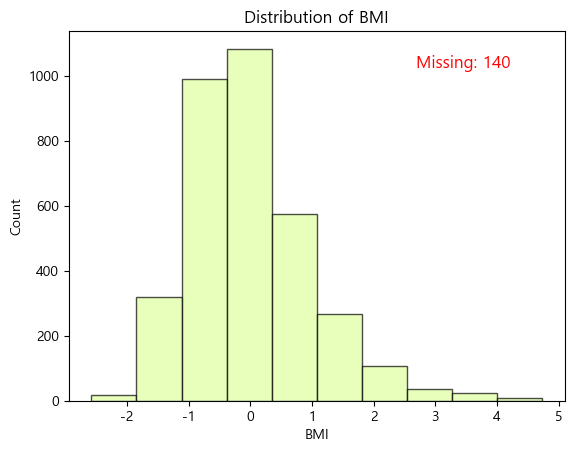

In [ ]:
# 결측치 확인
missing_values = data_original['bmi'].isnull()

# 결측치 포함한 히스토그램
plt.hist(data['bmi'], bins=10, alpha=0.7, edgecolor='black', color = '#DFFF9F')
plt.xlabel('BMI')
plt.ylabel('Count')
plt.title('Distribution of BMI')

# 결측치를 텍스트로 표시
missing_count = np.sum(missing_values)
plt.text(0.7, 0.9, f'Missing: {missing_count}', transform=plt.gca().transAxes, fontsize=12, color='red')

plt.show()

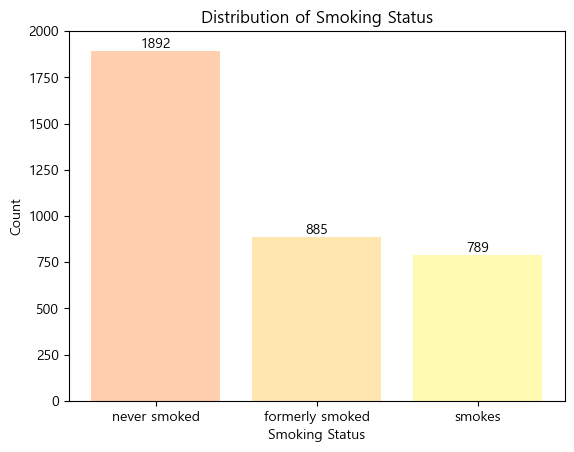

In [ ]:
# 흡연 여부 칼럼 값의 개수 계산
value_counts = data_original['smoking_status'].value_counts()

colors = ['#FFCFAF', '#FFE6AF', '#FFFAAF', '#DFFF9F']

# 시각화
plt.bar(value_counts.index, value_counts.values, color = colors)
plt.xlabel('Smoking Status')
plt.ylabel('Count')
plt.title('Distribution of Smoking Status')
plt.ylim(0, 2000)  # y 범위 설정 (start, end)
# 개수를 그래프에 텍스트로 표시
for i, count in enumerate(value_counts.values):
    plt.text(i, count, f'{count}', ha='center', va='bottom')

plt.show()

- 결측값 비율이 43%임

In [ ]:
df["smoking_status"].value_counts()

never smoked       1892
Unknown            1544
formerly smoked     885
smokes              789
Name: smoking_status, dtype: int64

In [ ]:
1544/(1892+884+789) * 100 # 결측값 비율 43%

43.30995792426368

In [ ]:
df = df.drop(df.loc[df["smoking_status"]=="Unknown"].index, axis = 0).copy() # Unkown이 있는 행 모두 삭제

In [ ]:
df["smoking_status"].value_counts()

never smoked       1892
formerly smoked     885
smokes              789
Name: smoking_status, dtype: int64

In [ ]:
df = df.loc[~df["bmi"].isna()] # bmi가 결측값이 아닌 행들만 가져옴

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 3426 entries, 0 to 5108
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 3426 non-null   int64  
 1   gender             3426 non-null   object 
 2   age                3426 non-null   float64
 3   hypertension       3426 non-null   int64  
 4   heart_disease      3426 non-null   int64  
 5   ever_married       3426 non-null   object 
 6   work_type          3426 non-null   object 
 7   Residence_type     3426 non-null   object 
 8   avg_glucose_level  3426 non-null   float64
 9   bmi                3426 non-null   float64
 10  smoking_status     3426 non-null   object 
 11  stroke             3426 non-null   int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 348.0+ KB


## 자료형 변경
- age 실수 -> 정수

In [ ]:
df = df.astype({"age":int})

In [ ]:
df["age"].dtype

dtype('int32')

## 이진화 / 더미변수
- gender
- ever_married
- Residence_type
- smoking_status
- work_type

In [ ]:
df['gender'] = df['gender'].apply(lambda x: 1 if x=='Male' else 0) # 이진화 
df['ever_married'] = df['ever_married'].apply(lambda x: 1 if x=='Yes' else 0)
df['Residence_type'] = df['Residence_type'].apply(lambda x: 1 if x=='Urban' else 0)

In [ ]:
# 더미변수 만들기
df = pd.get_dummies(df, columns = ['work_type','smoking_status']).copy()


In [ ]:
df.columns = df.columns.str.replace('work_type_', '') # 더미변수로 바꿀 때 고정적으로 붙는 접두어 삭제
df.columns = df.columns.str.replace('smoking_status_', '')


In [ ]:
# id 열은 필요 없으니까 삭제
df = df.drop(columns="id",axis=1)

In [ ]:
# stroke 맨뒤로 보내줌
# col2 열의 위치를 가져옴
col2_idx = df.columns.get_loc('stroke')

# 열 순서를 변경한 새로운 데이터프레임 생성
new_order = list(range(len(df.columns)))
new_order.pop(col2_idx)
new_order.append(col2_idx)
df = df.reindex(columns=df.columns[new_order])

## 표준화/정규화

- 정규화 : 데이터 셋 최솟값이 0이 되고, 데이터셋의 최대값 1 분포에 영향x

In [ ]:
from sklearn.preprocessing import StandardScaler

# StandardScaler 객체 생성
scaler = StandardScaler()

# 열들을 표준화
df[["age","avg_glucose_level","bmi"]] = scaler.fit_transform(df[["age","avg_glucose_level","bmi"]])
df.tail()


,gender,age,hypertension,heart_disease,ever_married,Residence_type,avg_glucose_level,bmi,Govt_job,Never_worked,Private,Self-employed,children,formerly smoked,never smoked,smokes,stroke
5100,1,1.769588,1,0,1,0,-0.762149,-0.272800,0,0,0,1,0,0,1,0,0
5102,0,0.443222,0,0,1,0,-0.637192,-1.177542,0,0,1,0,0,0,1,0,0
5106,0,1.716533,0,0,1,1,0.353864,1.331062,0,0,0,1,0,0,1,0,0
5107,0,-0.723981,0,0,1,0,-0.531105,0.042489,0,0,0,1,0,0,1,0,0
5108,1,0.124894,0,0,1,0,1.215352,-0.642922,0,0,1,0,0,1,0,0,0


- 이상치 추가처리(bmi)

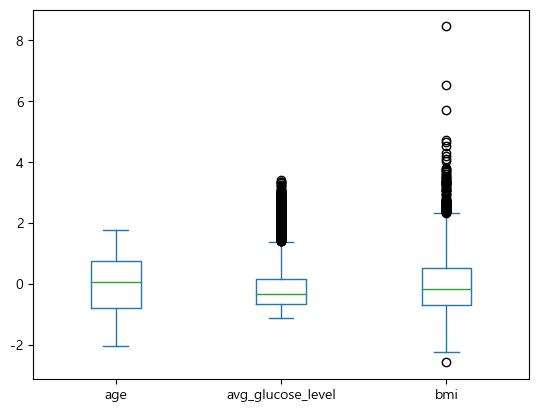

In [ ]:
df[["age","avg_glucose_level","bmi"]].plot.box()
plt.show()

- bmi 값에서 극단적인 값은 제거
- -2.5 보다 작은 값의 bmi는 어떻게 할까?

In [ ]:
# bmi 값이 5보다 큰 3개 행 제거 / # 544 928 4209/ 2187
df = df[df["bmi"]<5]


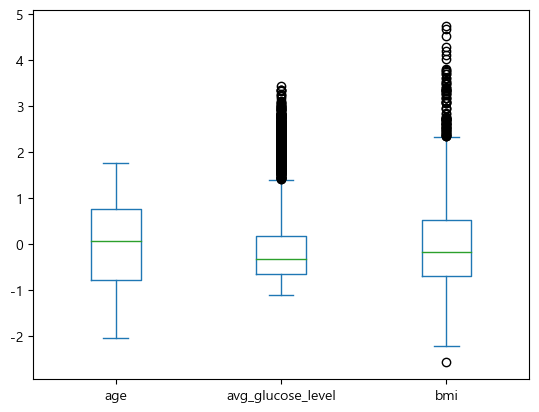

In [ ]:
df[["age","avg_glucose_level","bmi"]].plot.box()
plt.show()

## feature selection

In [ ]:
df_continuous = df[["age","bmi","avg_glucose_level"]]

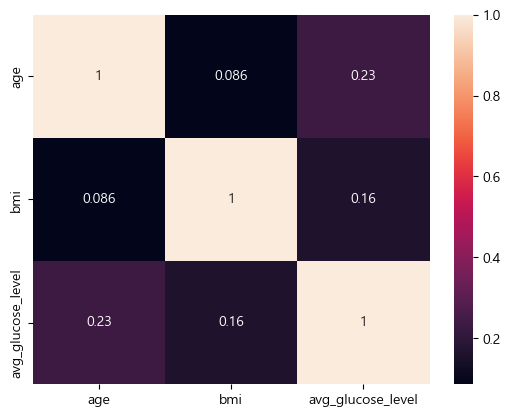

In [ ]:
corr_matrix = df_continuous.corr()
sns.heatmap(corr_matrix, annot=True)
plt.show()

In [ ]:
df_categorical = df.drop("stroke",axis=1).copy()

In [ ]:
df_categorical = df_categorical.drop(columns=["age","bmi","avg_glucose_level"],axis=1).copy()

In [ ]:
from scipy.stats import chi2_contingency
import numpy as np




def cramers_V(var1,var2) :
  crosstab =np.array(pd.crosstab(var1,var2, rownames=None, colnames=None)) # Cross table building
  stat = chi2_contingency(crosstab)[0] # Keeping of the test statistic of the Chi2 test
  obs = np.sum(crosstab) # Number of observations
  mini = min(crosstab.shape)-1 # Take the minimum value between the columns and the rows of the cross table
  return (stat/(obs*mini))

In [ ]:
rows= []

for var1 in df_categorical:
  col = []
  for var2 in df_categorical :
    cramers =cramers_V(df_categorical[var1], df_categorical[var2]) # Cramer's V test
    col.append(round(cramers,2)) # Keeping of the rounded value of the Cramer's V  
  rows.append(col)
  
cramers_results = np.array(rows)
df_selection = pd.DataFrame(cramers_results, columns = df_categorical.columns, index =df_categorical.columns)
df_selection

,gender,hypertension,heart_disease,ever_married,Residence_type,Govt_job,Never_worked,Private,Self-employed,children,formerly smoked,never smoked,smokes
gender,1.00,0.00,0.01,0.00,0.0,0.00,0.00,0.00,0.00,0.00,0.00,0.01,0.00
hypertension,0.00,1.00,0.01,0.01,0.0,0.00,0.00,0.00,0.01,0.00,0.00,0.00,0.00
heart_disease,0.01,0.01,0.99,0.01,0.0,0.00,0.00,0.00,0.00,0.00,0.00,0.01,0.00
ever_married,0.00,0.01,0.01,1.00,0.0,0.00,0.01,0.00,0.02,0.06,0.01,0.01,0.00
Residence_type,0.00,0.00,0.00,0.00,1.0,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
Govt_job,0.00,0.00,0.00,0.00,0.0,1.00,0.00,0.32,0.04,0.00,0.00,0.00,0.00
Never_worked,0.00,0.00,0.00,0.01,0.0,0.00,0.93,0.01,0.00,0.00,0.00,0.00,0.00
Private,0.00,0.00,0.00,0.00,0.0,0.32,0.01,1.00,0.40,0.04,0.00,0.00,0.00
Self-employed,0.00,0.01,0.00,0.02,0.0,0.04,0.00,0.40,1.00,0.00,0.01,0.00,0.00
children,0.00,0.00,0.00,0.06,0.0,0.00,0.00,0.04,0.00,0.99,0.00,0.00,0.00


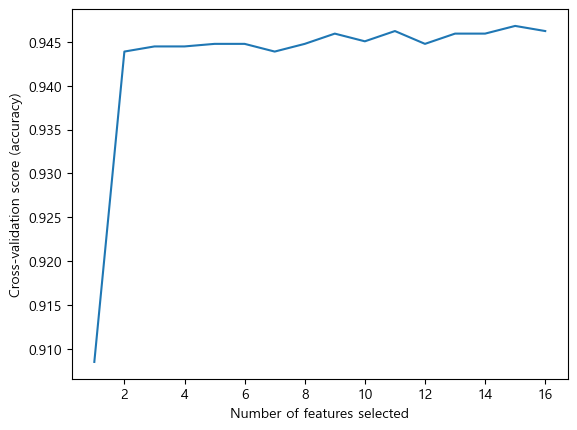

Selected Features:
Index(['gender', 'age', 'hypertension', 'heart_disease', 'ever_married',
       'Residence_type', 'avg_glucose_level', 'bmi', 'Govt_job', 'Private',
       'Self-employed', 'children', 'formerly smoked', 'never smoked',
       'smokes'],
      dtype='object')
Excluded Features:
Index(['Never_worked'], dtype='object')


In [ ]:
# 데이터를 특성(X)과 타겟(y)으로 분할
X = data.drop('stroke', axis=1)
y = data['stroke']

# 랜덤 포레스트 분류기 객체 생성
rf_classifier = RandomForestClassifier()

# RFECV 객체 생성
rfecv = RFECV(estimator=rf_classifier, step=1, cv=5, scoring='accuracy')

# RFECV로 feature selection 수행
rfecv.fit(X, y)

# 각 특성별로의 Cross-validation scores
cv_scores = rfecv.cv_results_['mean_test_score']

# 특성의 개수에 따른 Cross-validation scores의 변화를 시각화
plt.figure()
plt.xlabel("Number of features selected")
plt.ylabel("Cross-validation score (accuracy)")
plt.plot(range(1, len(cv_scores) + 1), cv_scores)
plt.show()

# 선택된 변수 출력
selected_features = X.columns[rfecv.support_]
print("Selected Features:")
print(selected_features)

# 선택되지 않은 변수 출력
excluded_features = X.columns[~rfecv.support_]
print("Excluded Features:")
print(excluded_features)

- 제거했을 때 정확도가 올라간 두 변수 제거 

In [ ]:
df.drop(['Never_worked', 'children'],axis=1,inplace=True)
data.drop(['Never_worked', 'children'],axis=1,inplace=True)

## 오버샘플링 후 랜덤포레스트

### SMOTE

In [ ]:
x = df.drop("stroke",axis = 1) #독립변수
y = df["stroke"] # 종속변수

In [ ]:
# train 과 test데이터를 미리나눠 test데이터의 독립성을 유지할 수 있게함
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size=0.3, random_state=42)

In [ ]:
# 오버 샘플링을 통해 불균형 데이터 처리
from imblearn.over_sampling import SMOTE

smote = SMOTE()
x_resampled_smote, y_resampled_smote = smote.fit_resample(x_train,y_train)  # train df에 대해서만 오버샘플링 진행함

# 분포 변화
print("before SMOTE :\n", y.value_counts()) # 기존 뇌졸중 비율 분포
print("\nbefore SMOTE :\n", y_resampled_smote.value_counts()) # 불균형 처리 후 뇌졸중 비율 분포

before SMOTE :
 0    3243
1     180
Name: stroke, dtype: int64

before SMOTE :
 0    2275
1    2275
Name: stroke, dtype: int64


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score, KFold

# train, test 데이터셋 분리
x_train, x_test, y_train, y_test = train_test_split(x_resampled_smote, y_resampled_smote, test_size=0.3, random_state=42)
# test_size : test 데이터와 train 데이터의 비율
# random_state : 매번 결과가 같게 해줌( 시드 설정)

# 랜덤 포레스트 모델 생성하기
random_forest = RandomForestClassifier(n_estimators=3, random_state=42)        # n_estimators=300 300개의 나무를 생성하겠다

# 모델 훈련하기
random_forest.fit(x_train, y_train)

# 예측하기
y_pred = random_forest.predict(x_test)

from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score, recall_score

# 정확도 계산
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

# 정밀도 계산
precision = precision_score(y_test, y_pred)
print("Precision:", precision)

# 재현율 계산
recall = recall_score(y_test, y_pred)
print("Recall:", recall)

Accuracy: 0.8688644688644689
Precision: 0.8317241379310345
Recall: 0.9136363636363637


## 언더샘플링 후 랜덤포레스트
- RandomUnderSampler
- NearMiss
- TomekLinks
- EditedNearestNeighbours
- OneSidedSelection

### RandomUnderSampler
- 랜덤으로 데이터 지움

In [ ]:
y.value_counts()

0    3243
1     180
Name: stroke, dtype: int64

In [ ]:
from imblearn.under_sampling import RandomUnderSampler


# 언더샘플링 수행
rus = RandomUnderSampler(random_state=42)
x_resampled_rus, y_resampled_rus = rus.fit_resample(x, y)

y_count = y_resampled_rus.value_counts()

# 언더샘플링된 데이터 확인
print(y_count)

0    180
1    180
Name: stroke, dtype: int64


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.ensemble import RandomForestClassifier


# 최적의 파라미터: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 300}
# 최적의 점수: 0.9067809038252388

# train, test 데이터셋 분리
x_train, x_test, y_train, y_test = train_test_split(x_resampled_rus, y_resampled_rus, test_size=0.3, random_state=42)
# test_size : test 데이터와 train 데이터의 비율
# random_state : 매번 결과가 같게 해줌( 시드 설정)


# 랜덤 포레스트 모델 생성하기
random_forest = RandomForestClassifier(n_estimators=300, 
                                       min_samples_split = 2,
                                       min_samples_leaf= 1,
                                       random_state=42)        # n_estimators=300 300개의 나무를 생성하겠다

# 모델 훈련하기
random_forest.fit(x_train, y_train)

# 예측하기
y_pred = random_forest.predict(x_test)


from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score, recall_score

# 정확도 계산
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

# 정밀도 계산
precision = precision_score(y_test, y_pred)
print("Precision:", precision)

# 재현율 계산
recall = recall_score(y_test, y_pred)
print("Recall:", recall)

# ROC curve를 계산합니다
fpr_rus, tpr_rus, thresholds = roc_curve(y_test, y_pred)

# AUC를 계산합니다
auc_rus = roc_auc_score(y_test, y_pred)


Accuracy: 0.8148148148148148
Precision: 0.7796610169491526
Recall: 0.8679245283018868


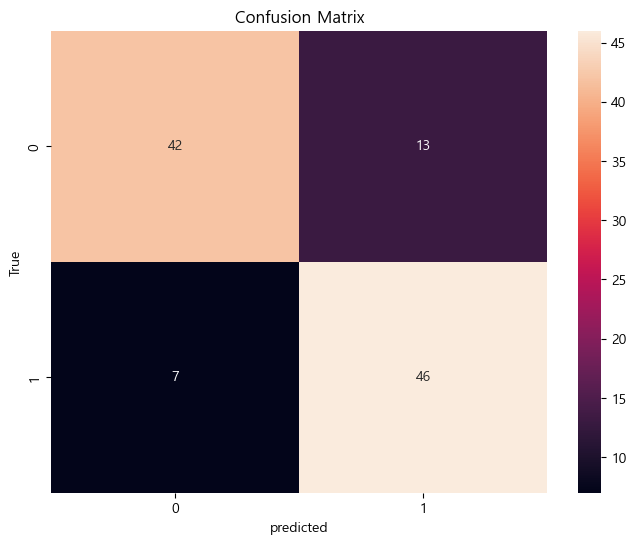

In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

# 히트맵 시각화
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel('predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

### TomekLinks
- 두 범주중에 가까운 것들끼리 link 된 후 다수 범주 제거 -> 분류경계에서 데이터가 제거됨

In [ ]:
from imblearn.under_sampling import TomekLinks

# 데이터와 레이블을 준비 (X: 독립변수, y: 종속변수)
x_resampled_tl, y_resampled_tl = TomekLinks().fit_resample(x, y)

# 데이터 불균형 해소 효과가 적음
y_resampled_tl.value_counts()

0    3156
1     180
Name: stroke, dtype: int64

In [ ]:
# train, test 데이터셋 분리
x_train, x_test, y_train, y_test = train_test_split(x_resampled_tl, y_resampled_tl, test_size=0.3, random_state=42)
# test_size : test 데이터와 train 데이터의 비율
# random_state : 매번 결과가 같게 해줌( 시드 설정)


# 랜덤 포레스트 모델 생성하기
random_forest = RandomForestClassifier(n_estimators=300, 
                                       min_samples_split = 2,
                                       min_samples_leaf= 1,
                                       random_state=42)        # n_estimators=300 300개의 나무를 생성하겠다

# 모델 훈련하기
random_forest.fit(x_train, y_train)

# 예측하기
y_pred = random_forest.predict(x_test)

# 정확도 계산
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

# 정밀도 계산
precision = precision_score(y_test, y_pred)
print("Precision:", precision)

# 재현율 계산
recall = recall_score(y_test, y_pred)
print("Recall:", recall)

# ROC curve를 계산합니다
fpr_tm, tpr_tm, thresholds = roc_curve(y_test, y_pred)

# AUC를 계산합니다
auc_ns0 = roc_auc_score(y_test, y_pred)

Accuracy: 0.939060939060939
Precision: 0.5
Recall: 0.01639344262295082


### NearMiss

Nearmiss-1 : Majority class examples with minimum average distance to three closest minority class examples.

In [ ]:
from imblearn.under_sampling import NearMiss

# 데이터와 레이블을 준비 (X: 독립변수, y: 종속변수)
x_resampled_ns1, y_resampled_ns1 = NearMiss(version=1).fit_resample(x, y)

y_resampled_ns1.value_counts()

0    180
1    180
Name: stroke, dtype: int64

In [ ]:
# train, test 데이터셋 분리
x_train, x_test, y_train, y_test = train_test_split(x_resampled_ns1, y_resampled_ns1, test_size=0.3, random_state=42)
# test_size : test 데이터와 train 데이터의 비율
# random_state : 매번 결과가 같게 해줌( 시드 설정)


# 랜덤 포레스트 모델 생성하기
random_forest = RandomForestClassifier(n_estimators=300, 
                                       min_samples_split = 2,
                                       min_samples_leaf= 1,
                                       random_state=42)        # n_estimators=300 300개의 나무를 생성하겠다

# 모델 훈련하기
random_forest.fit(x_train, y_train)

# 예측하기
y_pred = random_forest.predict(x_test)

# 정확도 계산
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

# 정밀도 계산
precision = precision_score(y_test, y_pred)
print("Precision:", precision)

# 재현율 계산
recall = recall_score(y_test, y_pred)
print("Recall:", recall)

# ROC curve를 계산합니다
fpr_ns1, tpr_ns1, thresholds = roc_curve(y_test, y_pred)

# AUC를 계산합니다
auc_ns1 = roc_auc_score(y_test, y_pred)

Accuracy: 0.7592592592592593
Precision: 0.7755102040816326
Recall: 0.7169811320754716


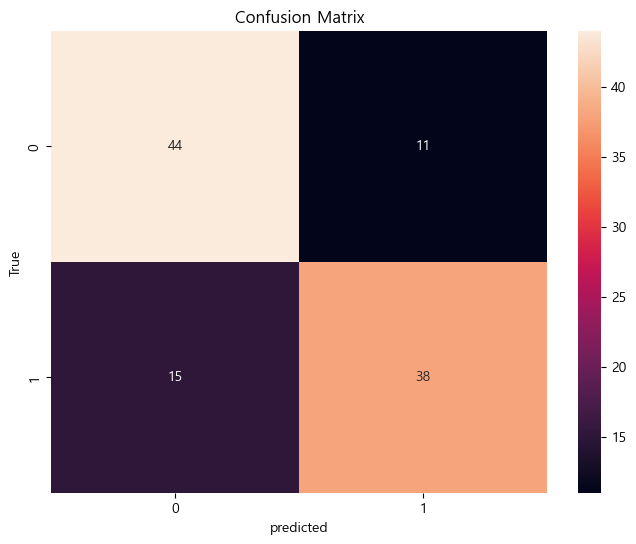

In [ ]:
cm = confusion_matrix(y_test, y_pred)

# 히트맵 시각화
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel('predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

NearMiss-2: Majority class examples with minimum average distance to three furthest minority class examples.
- 성능 제일 좋음

- MAE 값이 0에 가까움
- 정확도 정밀도 재현율 모두 높음
- FN 수가 가장 적음

In [ ]:
# 데이터와 레이블을 준비 (X: 독립변수, y: 종속변수)
x_resampled_ns2, y_resampled_ns2 = NearMiss(version=2).fit_resample(x, y)

y_resampled_ns2.value_counts()

0    180
1    180
Name: stroke, dtype: int64

In [ ]:
# train, test 데이터셋 분리
x_train, x_test, y_train, y_test = train_test_split(x_resampled_ns2, y_resampled_ns2, test_size=0.3, random_state=42)
# test_size : test 데이터와 train 데이터의 비율
# random_state : 매번 결과가 같게 해줌( 시드 설정)


# 랜덤 포레스트 모델 생성하기
random_forest = RandomForestClassifier(n_estimators=300, 
                                       min_samples_split = 2,
                                       min_samples_leaf= 1,
                                       random_state=42)        # n_estimators=300 300개의 나무를 생성하겠다

# 모델 훈련하기
random_forest.fit(x_train, y_train)

# 예측하기
y_pred = random_forest.predict(x_test)

# 정확도 계산
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

# 정밀도 계산
precision = precision_score(y_test, y_pred)
print("Precision:", precision)

# 재현율 계산
recall = recall_score(y_test, y_pred)
print("Recall:", recall)

# ROC curve를 계산합니다
fpr_ns2, tpr_ns2, thresholds = roc_curve(y_test, y_pred)

# AUC를 계산합니다
auc_ns2 = roc_auc_score(y_test, y_pred)


Accuracy: 0.8518518518518519
Precision: 0.8936170212765957
Recall: 0.7924528301886793


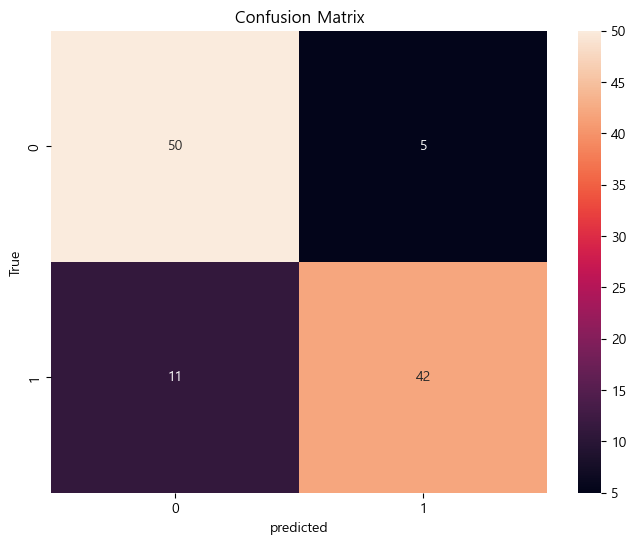

In [ ]:
cm = confusion_matrix(y_test, y_pred)

# 히트맵 시각화
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel('predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

NearMiss-3: Majority class examples with minimum distance to each minority class example.

In [ ]:
# 데이터와 레이블을 준비 (X: 독립변수, y: 종속변수)
x_resampled_ns3, y_resampled_ns3 = NearMiss(version=3).fit_resample(x, y)

y_resampled_ns3.value_counts()

0    180
1    180
Name: stroke, dtype: int64

In [ ]:
# train, test 데이터셋 분리
x_train, x_test, y_train, y_test = train_test_split(x_resampled_ns3, y_resampled_ns3, test_size=0.3, random_state=42)
# test_size : test 데이터와 train 데이터의 비율
# random_state : 매번 결과가 같게 해줌( 시드 설정)


# 랜덤 포레스트 모델 생성하기
random_forest = RandomForestClassifier(n_estimators=300, 
                                       min_samples_split = 2,
                                       min_samples_leaf= 1,
                                       random_state=42)        # n_estimators=300 300개의 나무를 생성하겠다

# 모델 훈련하기
random_forest.fit(x_train, y_train)

# 예측하기
y_pred = random_forest.predict(x_test)

# 정확도 계산
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

# 정밀도 계산
precision = precision_score(y_test, y_pred)
print("Precision:", precision)

# 재현율 계산
recall = recall_score(y_test, y_pred)
print("Recall:", recall)

# ROC curve를 계산합니다
fpr_ns3, tpr_ns3, thresholds = roc_curve(y_test, y_pred)

# AUC를 계산합니다
auc_ns3 = roc_auc_score(y_test, y_pred)

Accuracy: 0.6296296296296297
Precision: 0.6226415094339622
Recall: 0.6226415094339622


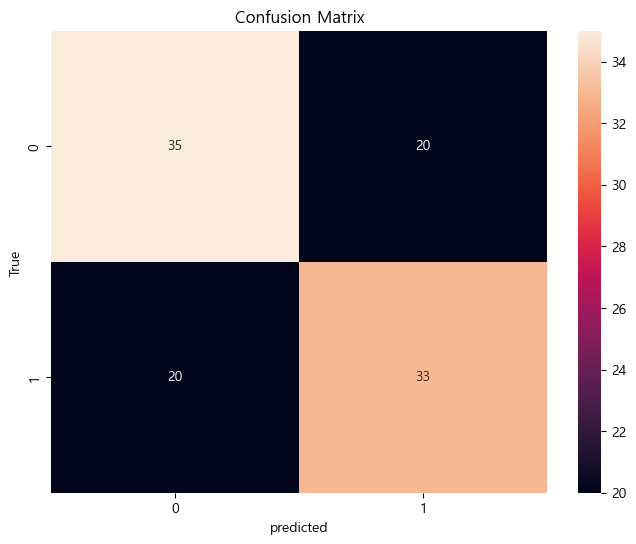

In [ ]:
cm = confusion_matrix(y_test, y_pred)

# 히트맵 시각화
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel('predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

### EditedNearestNeighbours

In [ ]:
from imblearn.under_sampling import EditedNearestNeighbours

# 데이터와 레이블을 준비 (X: 독립변수, y: 종속변수)
X_resampled_ens, y_resampled_ens = EditedNearestNeighbours().fit_resample(x, y)

y_resampled_ens.value_counts()

0    2836
1     180
Name: stroke, dtype: int64

### OneSidedSelection

In [ ]:
from imblearn.under_sampling import OneSidedSelection

# 데이터와 레이블을 준비 (X: 독립변수, y: 종속변수)
x_resampled_oss, y_resampled_oss = OneSidedSelection().fit_resample(x, y)

y_resampled_oss.value_counts()

0    3128
1     180
Name: stroke, dtype: int64

- 언더 샘플링 종류별 성능 시각화

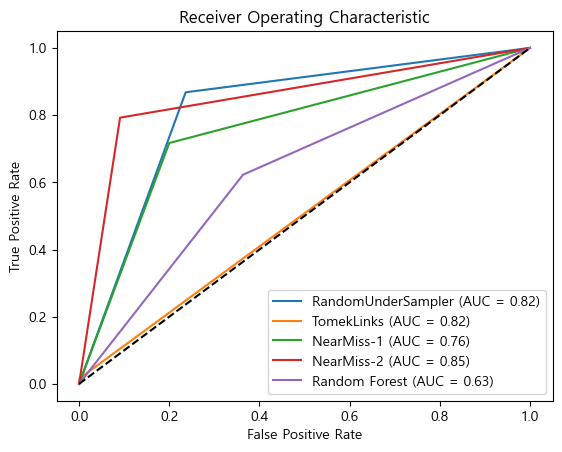

In [ ]:
# RandomUnderSampler의 ROC curve
plt.plot(fpr_rus, tpr_rus, label='RandomUnderSampler (AUC = %0.2f)' % auc_rus)
# TomekLinks의 ROC curve
plt.plot(fpr_tm, tpr_tm, label='TomekLinks (AUC = %0.2f)' % auc_rus)
# Nearmiss-1의 ROC curve
plt.plot(fpr_ns1, tpr_ns1, label='NearMiss-1 (AUC = %0.2f)' % auc_ns1)
# Nearmiss-2의 ROC curve
plt.plot(fpr_ns2, tpr_ns2, label='NearMiss-2 (AUC = %0.2f)' % auc_ns2)
# Nearmiss-3의 ROC curve
plt.plot(fpr_ns3, tpr_ns3, label='Random Forest (AUC = %0.2f)' % auc_ns3)

# 기준선 그리
plt.plot([0, 1], [0, 1], 'k--')

# 축과 범례 설정
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc='lower right')

# 그래프 출력
plt.show()

# 모델 선택

In [ ]:
x = data.drop("stroke",axis = 1) #독립변수
y = data["stroke"] # 종속변수
y.value_counts()

0    3242
1     180
Name: stroke, dtype: int64

In [ ]:
# 데이터와 레이블을 준비 (X: 독립변수, y: 종속변수)
x_resampled_ns2, y_resampled_ns2 = NearMiss(version=2).fit_resample(x, y)
y_resampled_ns2.value_counts()

0    180
1    180
Name: stroke, dtype: int64

## 로지스틱 회귀모형

In [ ]:
# 로지스틱 모델 초기화
model = LogisticRegression()

# 반복 실행 횟수 설정
n_iterations = 100

# accuracy score를 저장할 리스트 초기화
accuracy = []
precision = []
recall = []

# 반복문으로 모델 실행 및 accuracy score 저장
for _ in range(n_iterations):
    
    x_train, x_test, y_train, y_test = train_test_split(x_resampled_ns2, y_resampled_ns2, test_size=0.3)
    model.fit(x_train, y_train)
    
  
    y_pred = model.predict(x_test)
    
    # score 계산 및 리스트에 저장
    accuracy_value = accuracy_score(y_test, y_pred)
    accuracy.append(accuracy_value)
    precision_value = precision_score(y_test, y_pred)
    precision.append(precision_value)
    recall_value = recall_score(y_test, y_pred)
    recall.append(recall_value)
   

# 평균과 표준 편차 계산
accuracy_mean = np.mean(accuracy)
accuracy_std = np.std(accuracy)
precision_mean = np.mean(precision)
precision_std = np.std(precision)
recall_mean = np.mean(recall)
recall_std = np.std(recall)


print("평균 Accuracy :", accuracy_mean,"표준 편차:", accuracy_std)
print("평균 precision :", precision_mean, "표준 편차:", precision_std)
print("평균 recall :", recall_mean, "표준 편차:", recall_std)



평균 Accuracy : 0.6957407407407409 표준 편차: 0.035717705107717455
평균 precision : 0.7193529396083772 표준 편차: 0.05476660033584922
평균 recall : 0.6631034875698663 표준 편차: 0.06544365262563565


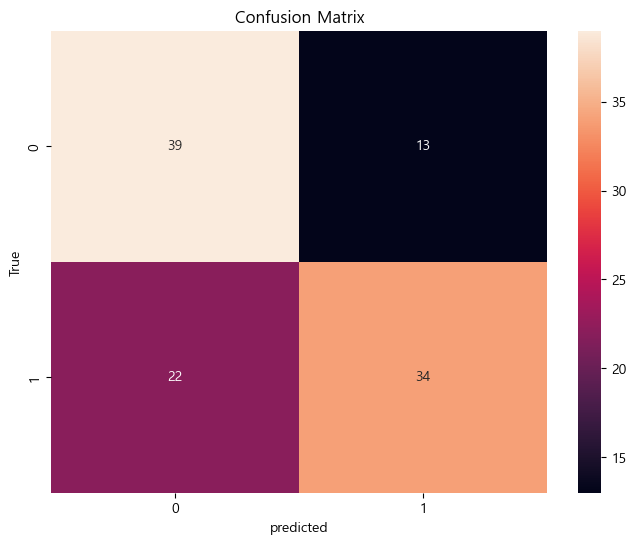

In [ ]:
cm = confusion_matrix(y_test, y_pred)

# 히트맵 시각화
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel('predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

## 랜덤포레스트 모델

In [ ]:

# 랜덤 포레스트 모델 초기화
random_forest = RandomForestClassifier()

# 반복 실행 횟수 설정
n_iterations = 100

# accuracy score를 저장할 리스트 초기화
accuracy = []
precision = []
recall = []
mae = []

# 반복문으로 모델 실행 및 accuracy score 저장
for _ in range(n_iterations):
    
    x_train, x_test, y_train, y_test = train_test_split(x_resampled_ns2, y_resampled_ns2, test_size=0.3)
    random_forest.fit(x_train, y_train)
    
  
    y_pred = random_forest.predict(x_test)
    
    # score 계산 및 리스트에 저장
    accuracy_value = accuracy_score(y_test, y_pred)
    accuracy.append(accuracy_value)
    precision_value = precision_score(y_test, y_pred)
    precision.append(precision_value)
    recall_value = recall_score(y_test, y_pred)
    recall.append(recall_value)
   

# 평균과 표준 편차 계산
accuracy_mean = np.mean(accuracy)
accuracy_std = np.std(accuracy)
precision_mean = np.mean(precision)
precision_std = np.std(precision)
recall_mean = np.mean(recall)
recall_std = np.std(recall)


print("평균 Accuracy :", accuracy_mean,"표준 편차:", accuracy_std)
print("평균 precision :", precision_mean, "표준 편차:", precision_std)
print("평균 recall :", recall_mean, "표준 편차:", recall_std)

평균 Accuracy : 0.8539814814814816 표준 편차: 0.03172171412103082
평균 precision : 0.8760268637433754 표준 편차: 0.05540838378460694
평균 recall : 0.8267583954572738 표준 편차: 0.05226908898382378


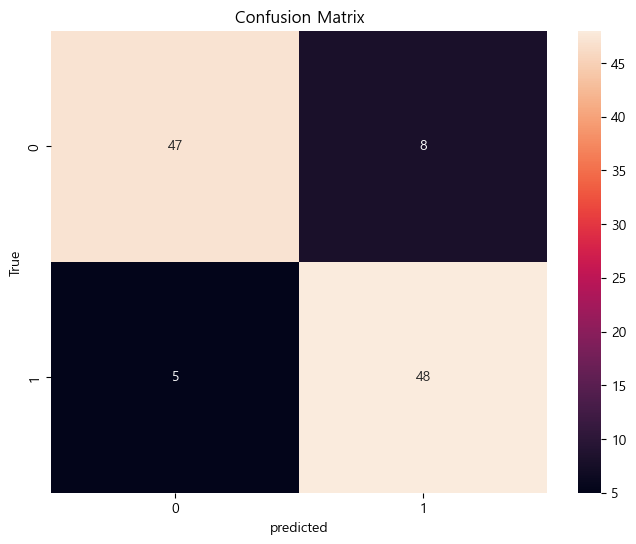

In [ ]:
cm = confusion_matrix(y_test, y_pred)

# 히트맵 시각화
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel('predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

- 밑에 주석으로 되어있는건 최적의 파라미터 찾는건데 돌리면 오래걸려서 다 주석처리 해놨어요

# 최적의 파라미터 랜덤포레스트

In [ ]:
# from sklearn.model_selection import GridSearchCV, train_test_split
# from sklearn.ensemble import RandomForestClassifier

# x_train, x_test, y_train, y_test = train_test_split(x_resampled_ns2, y_resampled_ns2, test_size=0.3, random_state=42)

# param_grid = {
#    'n_estimators': [100, 200, 300],
#     'max_depth': [None, 5, 10, 20],
#     'min_samples_split': [2, 5, 10],
#     'min_samples_leaf': [1, 2, 4]
# }

# rf = RandomForestClassifier(random_state=42)
# grid_search = GridSearchCV(rf, param_grid, cv=5, scoring='accuracy')
# grid_search.fit(x_train, y_train)

# print("최적의 파라미터:", grid_search.best_params_)
# print("최적의 점수:", grid_search.best_score_)

- 파라미터 설정을 안한게 더 성능이 좋게나옴 그래서 그냥 설정 안함

In [ ]:
#최적의 파라미터: {'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 300}
#최적의 점수: 0.8849411764705882

# 랜덤 포레스트 모델 초기화
random_forest = RandomForestClassifier()

# 반복 실행 횟수 설정
n_iterations = 100

# accuracy score를 저장할 리스트 초기화
accuracy = []
precision = []
recall = []
mae = []

# 반복문으로 모델 실행 및 accuracy score 저장
for _ in range(n_iterations):
    
    x_train, x_test, y_train, y_test = train_test_split(x_resampled_ns2, y_resampled_ns2, test_size=0.3)
    random_forest.fit(x_train, y_train)
    
  
    y_pred = random_forest.predict(x_test)
    
    # score 계산 및 리스트에 저장
    accuracy_value = accuracy_score(y_test, y_pred)
    accuracy.append(accuracy_value)
    precision_value = precision_score(y_test, y_pred)
    precision.append(precision_value)
    recall_value = recall_score(y_test, y_pred)
    recall.append(recall_value)
  

# 평균과 표준 편차 계산
accuracy_mean = np.mean(accuracy)
accuracy_std = np.std(accuracy)
precision_mean = np.mean(precision)
precision_std = np.std(precision)
recall_mean = np.mean(recall)
recall_std = np.std(recall)


print("평균 Accuracy :", accuracy_mean,"표준 편차:", accuracy_std)
print("평균 precision :", precision_mean, "표준 편차:", precision_std)
print("평균 recall :", recall_mean, "표준 편차:", recall_std)

평균 Accuracy : 0.846388888888889 표준 편차: 0.03624370244715886
평균 precision : 0.8710627946378762 표준 편차: 0.05246304885797456
평균 recall : 0.8181324703121653 표준 편차: 0.0513118300991392


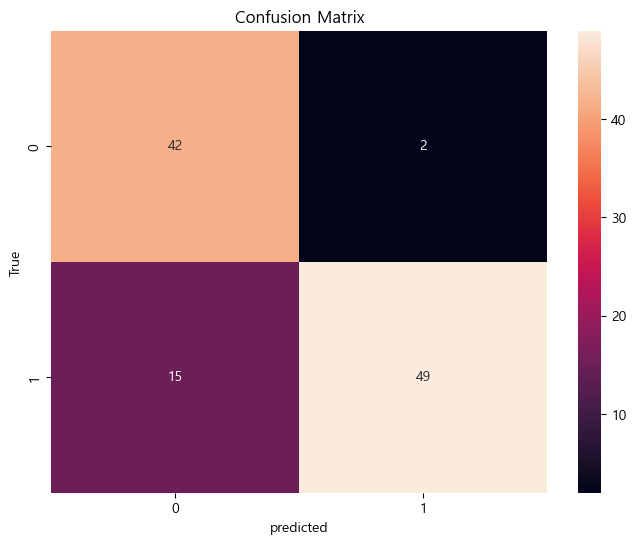

In [ ]:
cm = confusion_matrix(y_test, y_pred)

# 히트맵 시각화
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel('predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

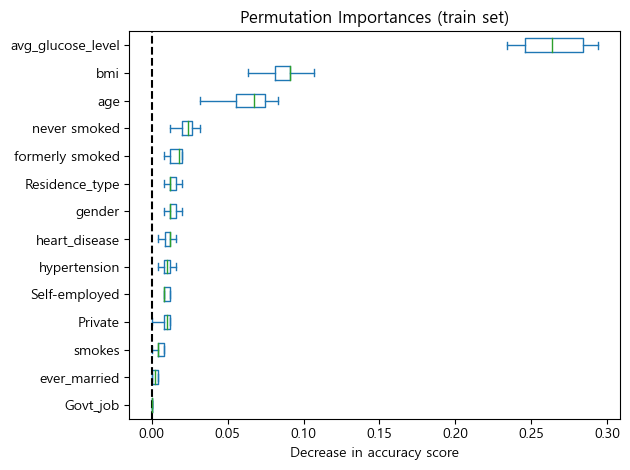

In [ ]:

result = permutation_importance(
    random_forest, x_train, y_train, n_repeats=10, random_state=42, n_jobs=2
)

sorted_importances_idx = result.importances_mean.argsort()
importances = pd.DataFrame(
    result.importances[sorted_importances_idx].T,
    columns=x.columns[sorted_importances_idx],
)
ax = importances.plot.box(vert=False, whis=10)
ax.set_title("Permutation Importances (train set)")
ax.axvline(x=0, color="k", linestyle="--")
ax.set_xlabel("Decrease in accuracy score")
ax.figure.tight_layout()

# 추가분석

In [ ]:
not_normalized_data = pd.read_csv("data/not normalized dataset")
not_normalized_data.drop(['Never_worked', 'children'],axis=1,inplace=True)

## glucose level 126 이상(당뇨병), bmi 30 이상(비만)

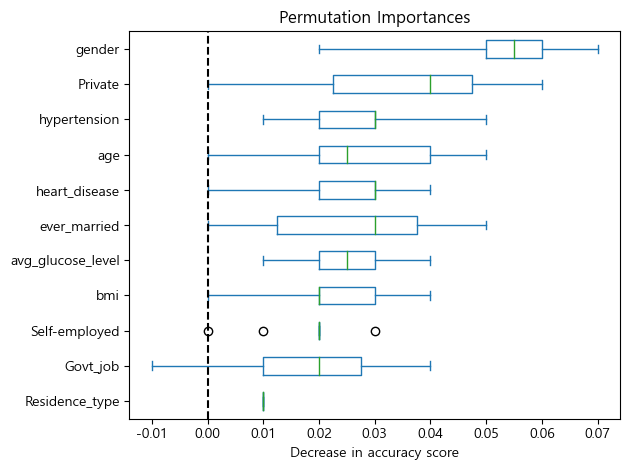

In [ ]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
import eli5
from eli5.sklearn import PermutationImportance

# Subgroup 조건
glucose_threshold = 126
bmi_threshold = 30

# Subgroup 데이터 추출
subgroup_data = not_normalized_data[(not_normalized_data['age'] >= 70) & (not_normalized_data['avg_glucose_level'] >= glucose_threshold) & (not_normalized_data['bmi'] >= bmi_threshold)].copy()
subgroup_data = subgroup_data.drop(['age','avg_glucose_level','bmi'], axis=1)

# Features와 Target 분리
X = subgroup_data.drop('stroke', axis=1)
y = subgroup_data['stroke']

# Random Forest 모델 학습
model = RandomForestClassifier()
model.fit(X, y)


result = permutation_importance(
    model, X, y, n_repeats=10, random_state=42, n_jobs=2
)

sorted_importances_idx = result.importances_mean.argsort()
importances = pd.DataFrame(
    result.importances[sorted_importances_idx].T,
    columns=x.columns[sorted_importances_idx],
)
ax = importances.plot.box(vert=False, whis=10)
ax.set_title("Permutation Importances")
ax.axvline(x=0, color="k", linestyle="--")
ax.set_xlabel("Decrease in accuracy score")
ax.figure.tight_layout()


##  glucose level 126 이하(당뇨병X), bmi 30 이상(비만)

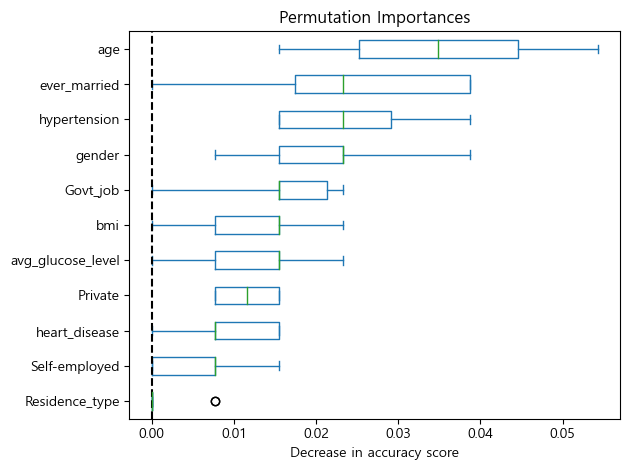

In [ ]:
# Subgroup 조건
glucose_threshold = 126
bmi_threshold = 30

# Subgroup 데이터 추출
subgroup_data = not_normalized_data[(not_normalized_data['age'] >= 70) & (not_normalized_data['avg_glucose_level'] < glucose_threshold) & (not_normalized_data['bmi'] >= bmi_threshold)].copy()
subgroup_data = subgroup_data.drop(['age','avg_glucose_level','bmi'], axis=1)

# Features와 Target 분리
X = subgroup_data.drop('stroke', axis=1)
y = subgroup_data['stroke']

# Random Forest 모델 학습
model = RandomForestClassifier()
model.fit(X, y)

# permutation importance 계산
result = permutation_importance(
    model, X, y, n_repeats=10, random_state=42, n_jobs=2
)

sorted_importances_idx = result.importances_mean.argsort()
importances = pd.DataFrame(
    result.importances[sorted_importances_idx].T,
    columns=x.columns[sorted_importances_idx],
)
ax = importances.plot.box(vert=False, whis=10)
ax.set_title("Permutation Importances")
ax.axvline(x=0, color="k", linestyle="--")
ax.set_xlabel("Decrease in accuracy score")
ax.figure.tight_layout()

## glucose level 126 이상(당뇨병), bmi 30 미만(비만X)

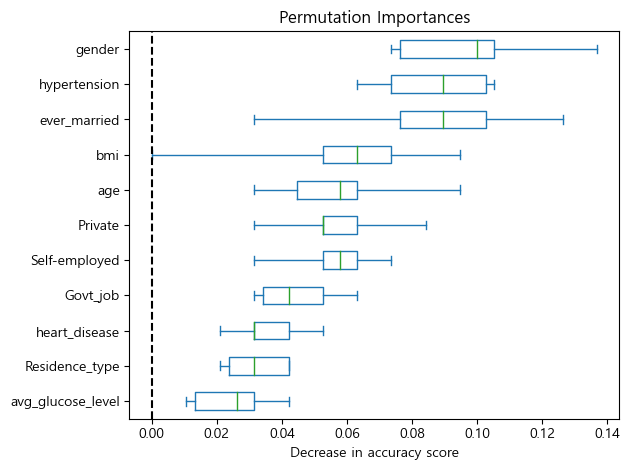

In [ ]:
# Subgroup 조건
glucose_threshold = 126
bmi_threshold = 30

# Subgroup 데이터 추출
subgroup_data = not_normalized_data[(not_normalized_data['age'] >= 70) & (not_normalized_data['avg_glucose_level'] >= glucose_threshold) & (not_normalized_data['bmi'] < bmi_threshold)].copy()
subgroup_data = subgroup_data.drop(['age','avg_glucose_level','bmi'], axis=1)

# Features와 Target 분리
X = subgroup_data.drop('stroke', axis=1)
y = subgroup_data['stroke']

# Random Forest 모델 학습
model = RandomForestClassifier()
model.fit(X, y)

# permutation importance 계산
result = permutation_importance(
    model, X, y, n_repeats=10, random_state=42, n_jobs=2
)

sorted_importances_idx = result.importances_mean.argsort()
importances = pd.DataFrame(
    result.importances[sorted_importances_idx].T,
    columns=x.columns[sorted_importances_idx],
)
ax = importances.plot.box(vert=False, whis=10)
ax.set_title("Permutation Importances")
ax.axvline(x=0, color="k", linestyle="--")
ax.set_xlabel("Decrease in accuracy score")
ax.figure.tight_layout()

## 70대만 

In [ ]:
data_70s = data.iloc[age70_index]

In [ ]:
x_70s = data_70s.drop("stroke",axis = 1) #독립변수
y_70s = data_70s["stroke"] # 종속변수
y.value_counts()

0    71
1    24
Name: stroke, dtype: int64

In [ ]:
# 데이터와 레이블을 준비 (X: 독립변수, y: 종속변수)
x_resampled_ns2, y_resampled_ns2 = NearMiss(version=2).fit_resample(x_70s, y_70s)
y_resampled_ns2.value_counts()

0    63
1    63
Name: stroke, dtype: int64

In [ ]:

# 랜덤 포레스트 모델 초기화
random_forest = RandomForestClassifier()

# 반복 실행 횟수 설정
n_iterations = 100

# accuracy score를 저장할 리스트 초기화
accuracy = []
precision = []
recall = []
mae = []

# 반복문으로 모델 실행 및 accuracy score 저장
for _ in range(n_iterations):
    
    x_train, x_test, y_train, y_test = train_test_split(x_resampled_ns2, y_resampled_ns2, test_size=0.3)
    random_forest.fit(x_train, y_train)
    
  
    y_pred = random_forest.predict(x_test)
    
    # score 계산 및 리스트에 저장
    accuracy_value = accuracy_score(y_test, y_pred)
    accuracy.append(accuracy_value)
    precision_value = precision_score(y_test, y_pred)
    precision.append(precision_value)
    recall_value = recall_score(y_test, y_pred)
    recall.append(recall_value)
   

# 평균과 표준 편차 계산
accuracy_mean = np.mean(accuracy)
accuracy_std = np.std(accuracy)
precision_mean = np.mean(precision)
precision_std = np.std(precision)
recall_mean = np.mean(recall)
recall_std = np.std(recall)


print("평균 Accuracy :", accuracy_mean,"표준 편차:", accuracy_std)
print("평균 precision :", precision_mean, "표준 편차:", precision_std)
print("평균 recall :", recall_mean, "표준 편차:", recall_std)



평균 Accuracy : 0.705526315789474 표준 편차: 0.06212923266262459
평균 precision : 0.7508979111909015 표준 편차: 0.12187293795866559
평균 recall : 0.6490232864819181 표준 편차: 0.11211607084206071


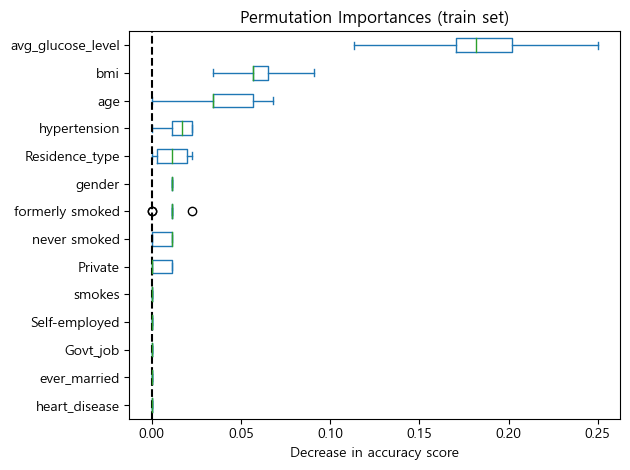

In [ ]:

result = permutation_importance(
    random_forest, x_train, y_train, n_repeats=10, random_state=42, n_jobs=2
)

sorted_importances_idx = result.importances_mean.argsort()
importances = pd.DataFrame(
    result.importances[sorted_importances_idx].T,
    columns=x.columns[sorted_importances_idx],
)
ax = importances.plot.box(vert=False, whis=10)
ax.set_title("Permutation Importances (train set)")
ax.axvline(x=0, color="k", linestyle="--")
ax.set_xlabel("Decrease in accuracy score")
ax.figure.tight_layout()

## 중요변수 3개(bmi,age,avg_glucose_level 삭제)

In [ ]:
data_drop_importance = data.drop(["age","bmi","avg_glucose_level"],axis=1)

In [ ]:
x = data_drop_importance.drop("stroke",axis = 1) #독립변수
y = data_drop_importance["stroke"] # 종속변수
y.value_counts()

0    3242
1     180
Name: stroke, dtype: int64

In [ ]:
# 데이터와 레이블을 준비 (X: 독립변수, y: 종속변수)
x_resampled_ns2, y_resampled_ns2 = NearMiss(version=2).fit_resample(x, y)
y_resampled_ns2.value_counts()

0    180
1    180
Name: stroke, dtype: int64

In [ ]:

# 랜덤 포레스트 모델 초기화
random_forest = RandomForestClassifier()

# 반복 실행 횟수 설정
n_iterations = 100

# accuracy score를 저장할 리스트 초기화
accuracy = []
precision = []
recall = []
mae = []
accuracy_train = []
precision_train = []
recall_train = []
mae_train = []

# 반복문으로 모델 실행 및 accuracy score 저장
for _ in range(n_iterations):
    
    x_train, x_test, y_train, y_test = train_test_split(x_resampled_ns2, y_resampled_ns2, test_size=0.3)
    random_forest.fit(x_train, y_train)
    
  
    y_pred = random_forest.predict(x_test)
    y_val = random_forest.predict(x_train)
    
    # score 계산 및 리스트에 저장
    accuracy_value = accuracy_score(y_test, y_pred)
    accuracy.append(accuracy_value)
    precision_value = precision_score(y_test, y_pred)
    precision.append(precision_value)
    recall_value = recall_score(y_test, y_pred)
    recall.append(recall_value)
   


# 평균과 표준 편차 계산
accuracy_mean = np.mean(accuracy)
accuracy_std = np.std(accuracy)
precision_mean = np.mean(precision)
precision_std = np.std(precision)
recall_mean = np.mean(recall)
recall_std = np.std(recall)



print("평균 Accuracy :", accuracy_mean,"표준 편차:", accuracy_std)
print("평균 precision :", precision_mean, "표준 편차:", precision_std)
print("평균 recall :", recall_mean, "표준 편차:", recall_std)



평균 Accuracy : 0.9362037037037038 표준 편차: 0.020947014938703067
평균 precision : 1.0 표준 편차: 0.0
평균 recall : 0.8728491975560475 표준 편차: 0.04111427664333388


In [ ]:
train_score = random_forest.score(x_train,y_train)
test_score = random_forest.score(x_test,y_test)
print(train_score)
print(test_score)

0.9404761904761905
0.9444444444444444


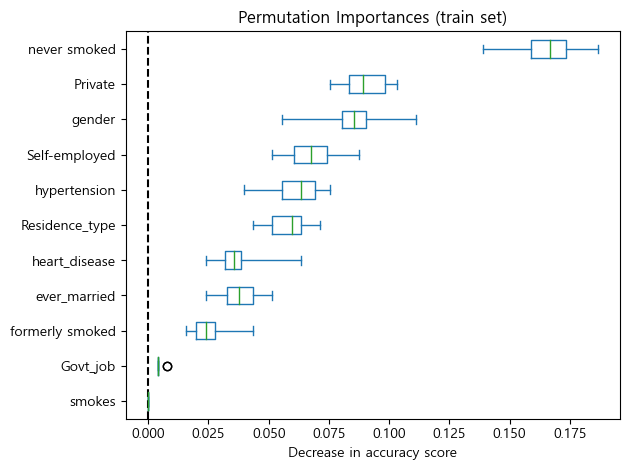

In [ ]:

result = permutation_importance(
    random_forest, x_train, y_train, n_repeats=10, random_state=42, n_jobs=2
)

sorted_importances_idx = result.importances_mean.argsort()
importances = pd.DataFrame(
    result.importances[sorted_importances_idx].T,
    columns=x.columns[sorted_importances_idx],
)
ax = importances.plot.box(vert=False, whis=10)
ax.set_title("Permutation Importances (train set)")
ax.axvline(x=0, color="k", linestyle="--")
ax.set_xlabel("Decrease in accuracy score")
ax.figure.tight_layout()